In [317]:
import numpy as np 
import math
import rebound
import astropy.units as u
import astropy.constants as const
import matplotlib
import matplotlib.pyplot as plt

## Problem 3

### Parte a) 

HAT-P-13 radius is given by $\text{1.73}_{\text{-0.09}}^{\text{+0.10}}$ $R_{\odot}$ and b's semimajor axis is given by $\text{0.04313}_{\text{-0.00026}}^{\text{+0.00033}}$ [AU]. Replacing both values on Equation \ref{transitprobabilityeq}, we get:

In [12]:
radio_estrella = 1.73*u.R_sun
semieje_mayor_b = 0.04313*u.AU
semieje_mayor_c = 1.188*u.AU

In [13]:
prob_transit_b = (radio_estrella.to(u.AU))/(semieje_mayor_b)

In [14]:
prob_transit_c = (radio_estrella.to(u.AU))/(semieje_mayor_c)

In [15]:
prob_transit_b,prob_transit_c

(<Quantity 0.18653625>, <Quantity 0.00677215>)

### Parte b) i)

In [351]:
prob_transit_b*prob_transit_c

<Quantity 0.00126325>

### Parte b) ii)

### Parte c)

In [114]:
mass_star = 1.261
mass_b = 0.906*const.M_jup.to(u.M_sun).value
mass_c = 14.28*const.M_jup.to(u.M_sun).value

In [398]:
baseline_time = 3   # years


# Solo B

sim1 = rebound.Simulation()
#sim1.units = ('yr', 'AU', 'Msun')
sim1.add(m = mass_star)             
sim1.add(m = mass_b, a = 0.04313, e = 0.0093,  inc = 0)    
sim1.integrate(baseline_time)
planet_b1 = sim1.particles[1]  

# Solo C

sim2 = rebound.Simulation()
sim2.add(m = mass_star)             
sim2.add(m = mass_c, a = 1.188,   e = 0.6616, inc = 0)

sim2.integrate(baseline_time)
planet_c1 = sim2.particles[1]  

# Ambos planetas

sim3 = rebound.Simulation()
sim3.add(m = mass_star)            
sim3.add(m = mass_b, a = 0.04313, e = 0.0093,   inc = 0)    
sim3.add(m = mass_c, a = 1.188,   e = 0.6616,   inc = 0)

sim3.integrate(baseline_time)
planet_b2 = sim3.particles[1]  
planet_c2 = sim3.particles[2]  





In [399]:
sim1.integrator = "whfast"
sim1.dt = 0.05/(2*np.pi) #notamos que las unidades están en yrs/2pi

sim2.integrator = "whfast"
sim2.dt = 0.05/(2*np.pi)

sim3.integrator = "whfast"
sim3.dt = 0.05/(2*np.pi)

tmax = 3*(2*np.pi)      #por temas de unidades, 10*2pi yrs/2pi es equivalente a 10yrs
Nout = 80

In [400]:
times = np.linspace(0,tmax,Nout)

vx1 = np.zeros(Nout)

vx2 = np.zeros(Nout)

vx31 = np.zeros(Nout)
vx32 = np.zeros(Nout)

particles1 = sim1.particles
sim1.move_to_com() #centro de masa

particles2 = sim2.particles
sim2.move_to_com() #centro de masa

particles3 = sim3.particles
sim3.move_to_com() #centro de masa

for i,time in enumerate(times):
    sim1.integrate(time)
    vx1[i] = particles1[1].vx

for i,time in enumerate(times):
    sim2.integrate(time)
    vx2[i] = particles2[1].vx

for i,time in enumerate(times):
    sim3.integrate(time)
    vx31[i] = particles3[1].vx
    vx32[i] = particles3[2].vx


Text(0.5, 0, 'Years')

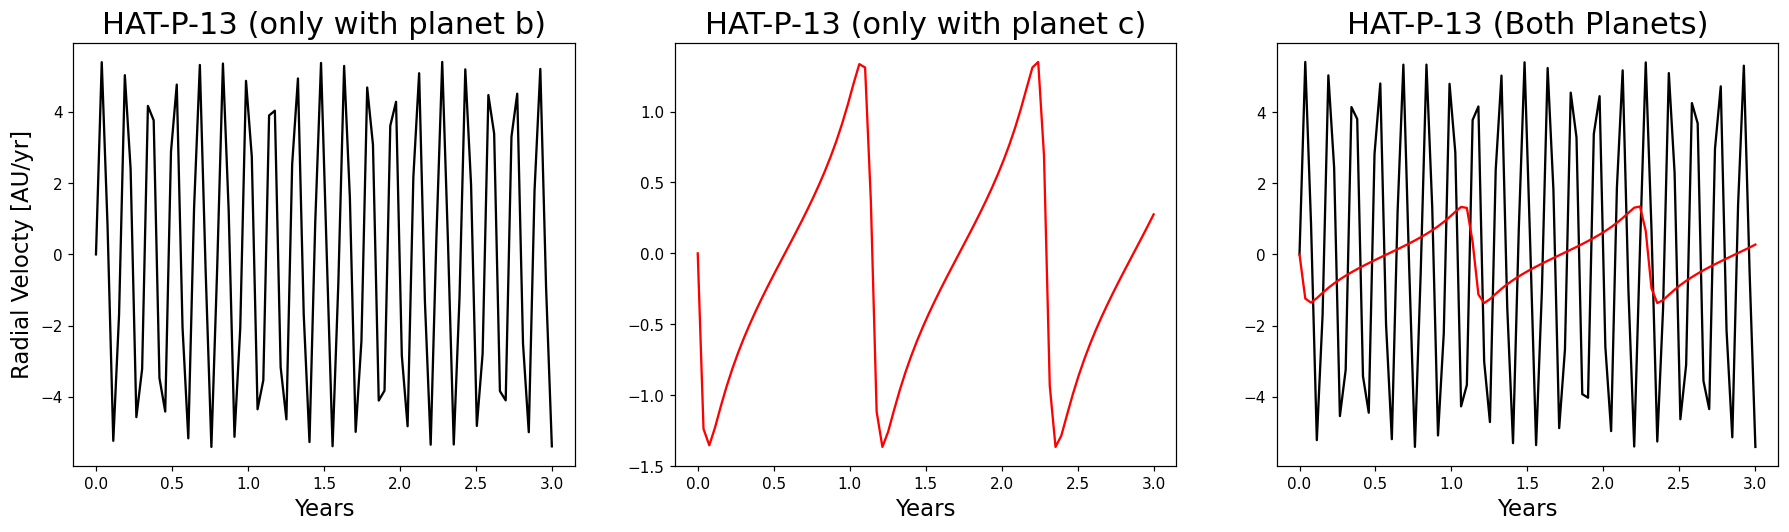

In [401]:
fig = plt.figure(figsize=(20, 5),dpi=110)
gs = matplotlib.gridspec.GridSpec(1, 3, width_ratios=[1,1,1])
#fig.suptitle('Original and continuum subtracted spectra',fontsize=20)

ax0 = plt.subplot(gs[0])
ax0.set_title('HAT-P-13 (only with planet b)',fontsize=20)
ax0.plot(times/(2*np.pi), vx1, c='black')
ax0.set_xlabel('Years',fontsize=15)
ax0.set_ylabel('Radial Velocty [AU/yr]',fontsize=15)

ax1 = plt.subplot(gs[1])
ax1.set_title('HAT-P-13 (only with planet c)',fontsize=20)
ax1.plot(times/(2*np.pi), vx2, c='red')
ax1.set_xlabel('Years',fontsize=15)


ax2 = plt.subplot(gs[2])
ax2.set_title('HAT-P-13 (Both Planets)',fontsize=20)
ax2.plot(times/(2*np.pi), vx31, c='black')
ax2.plot(times/(2*np.pi), vx32, c='red')
ax2.set_xlabel('Years',fontsize=15)


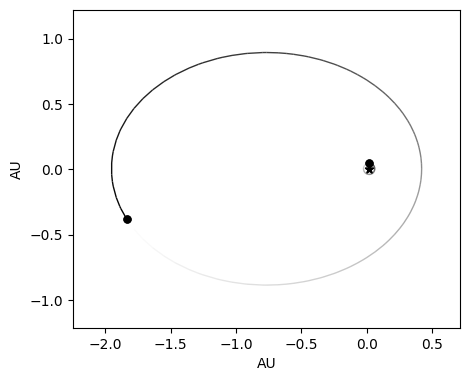

In [402]:
fig = rebound.OrbitPlot(sim3)
plt.xlabel('AU')
plt.ylabel('AU')
plt.show()


## Pregunta 4

 ### Integrate the system for 100 years setting $f=\Omega=I=0$, $\omega=\pi/2$, and plot $a_b$ and $e_b$. Is the evolution conserving orbital energy of planet b?, what happens to its eccentricity?


In [407]:
sim4 = rebound.Simulation()

sim4.add(m = mass_star)            
sim4.add(m = mass_b, a = 0.04313, e = 0.0093,   inc = 0,omega=np.pi/2,f=0,Omega=0)    
sim4.add(m = mass_c, a = 1.188,   e = 0.6616,   inc = 0,omega=np.pi/2,f=0,Omega=0)

sim4.integrate(baseline_time)
planet_b4 = sim4.particles[1]  
planet_c4 = sim4.particles[2]  


In [408]:
sim4.integrator = "whfast"
sim4.dt = 0.05/(2*np.pi)
tmax = 100*(2*np.pi)      #por temas de unidades, 10*2pi yrs/2pi es equivalente a 10yrs
Nout = 200

In [409]:
times = np.linspace(0,tmax,Nout)

eb,ec = np.zeros(Nout),np.zeros(Nout)
ab,ac = np.zeros(Nout),np.zeros(Nout)
energy = np.zeros(Nout)

particles4 = sim4.particles
sim4.move_to_com() #centro de masa

for i,time in enumerate(times):
    sim4.integrate(time)
    eb[i] = particles4[1].e
    ab[i] = particles4[1].a


Text(0, 0.5, 'Eccentricity')

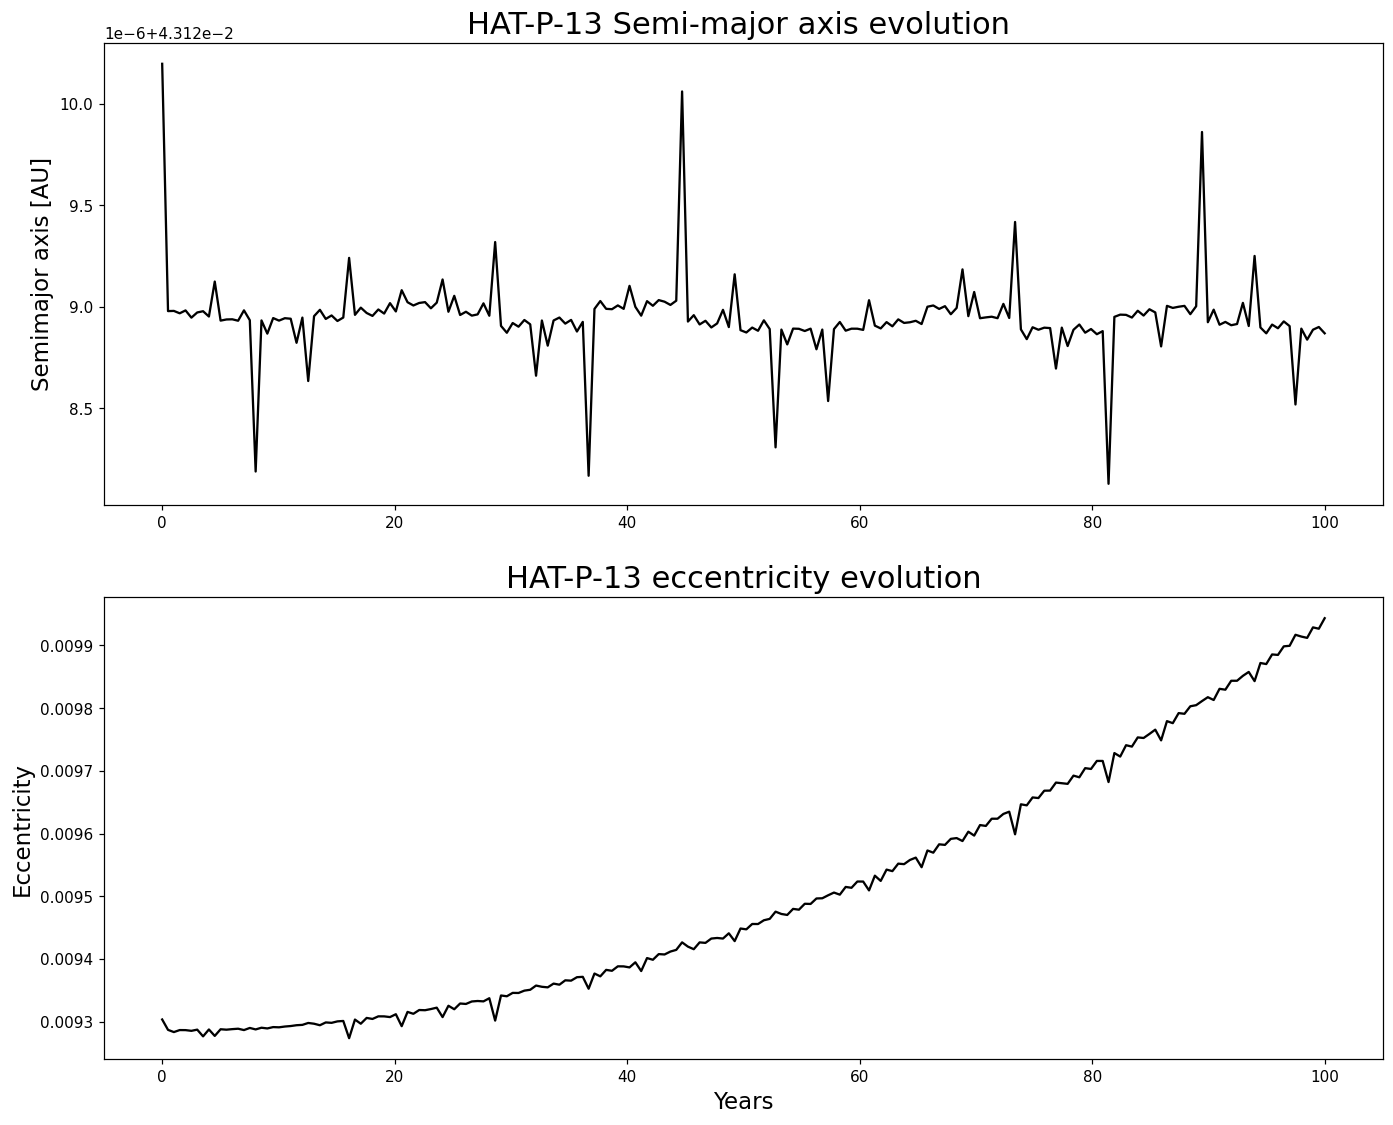

In [410]:
fig = plt.figure(figsize=(15, 12),dpi=110)
gs = matplotlib.gridspec.GridSpec(2, 1, width_ratios=[1])
#fig.suptitle('Original and continuum subtracted spectra',fontsize=20)

ax0 = plt.subplot(gs[0])
ax0.set_title('HAT-P-13 Semi-major axis evolution ',fontsize=20)
ax0.plot(times/(2*np.pi), ab, c='black')
#ax0.plot(times/(2*np.pi), eb, c='red')
#ax0.set_xlabel('Years',fontsize=15)
ax0.set_ylabel('Semimajor axis [AU]',fontsize=15)


ax1 = plt.subplot(gs[1])
ax1.set_title('HAT-P-13 eccentricity evolution',fontsize=20)
ax1.plot(times/(2*np.pi), eb, c='black')
ax1.set_xlabel('Years',fontsize=15)
ax1.set_ylabel('Eccentricity',fontsize=15)



### Repeat the exercise by placing planet b at $a_b=0.2$ au. How does the result change?

In [414]:
sim5 = rebound.Simulation()
sim5.add(m = mass_star)            
sim5.add(m = mass_b, a = 0.2, e = 0.0093,   inc = 0,omega=np.pi/2,f=0,Omega=0)    
sim5.add(m = mass_c, a = 1.188,   e = 0.6616,   inc = 0,omega=np.pi/2,f=0,Omega=0)
sim5.integrate(baseline_time)
planet_b5 = sim5.particles[1]  
planet_c5 = sim5.particles[2]  


In [415]:
sim5.integrator = "whfast"
sim5.dt = 0.05/(2*np.pi)
tmax = 100*(2*np.pi)      #por temas de unidades, 10*2pi yrs/2pi es equivalente a 10yrs
Nout = 200

In [419]:
times = np.linspace(0,tmax,Nout)

ebf,ecf = np.zeros(Nout),np.zeros(Nout)
abf,acf = np.zeros(Nout),np.zeros(Nout)

particles5 = sim5.particles
sim5.move_to_com() #centro de masa

for i,time in enumerate(times):
    sim5.integrate(time)
    ebf[i] = particles5[1].e
    abf[i] = particles5[1].a


Text(0, 0.5, 'Eccentricity')

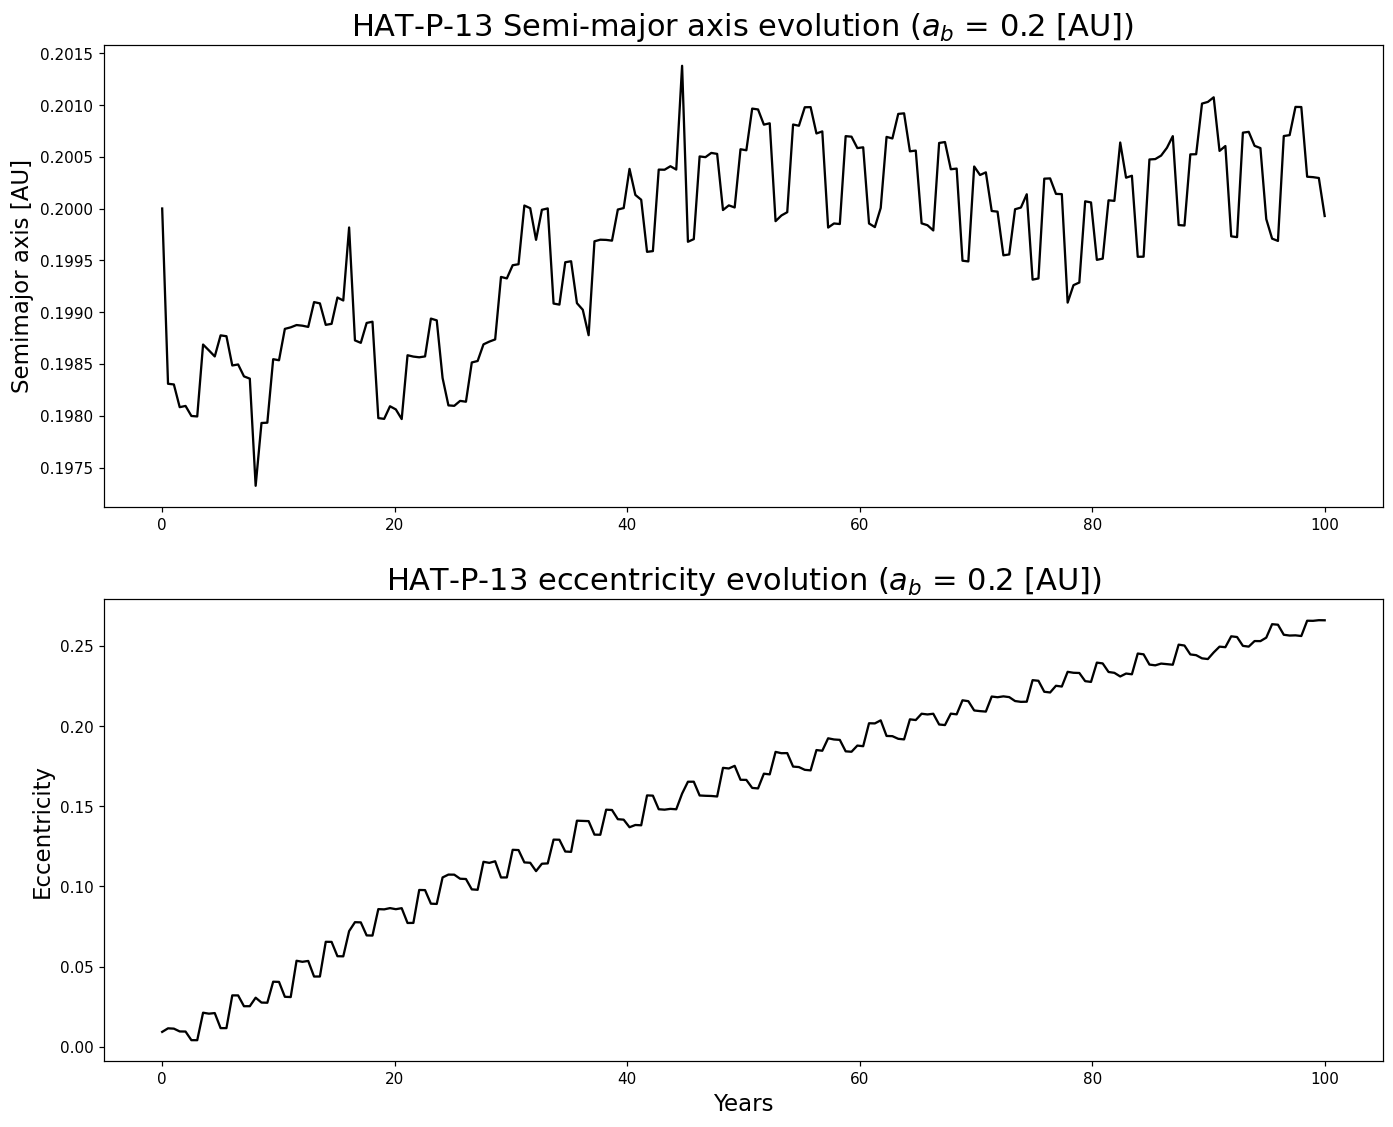

In [421]:
fig = plt.figure(figsize=(15, 12),dpi=110)
gs = matplotlib.gridspec.GridSpec(2, 1, width_ratios=[1])
#fig.suptitle('Original and continuum subtracted spectra',fontsize=20)

ax0 = plt.subplot(gs[0])
ax0.set_title('HAT-P-13 Semi-major axis evolution ($a_{b}$ = 0.2 [AU]) ',fontsize=20)
ax0.plot(times/(2*np.pi), abf, c='black')
#ax0.plot(times/(2*np.pi), eb, c='red')
#ax0.set_xlabel('Years',fontsize=15)
ax0.set_ylabel('Semimajor axis [AU]',fontsize=15)


ax1 = plt.subplot(gs[1])
ax1.set_title('HAT-P-13 eccentricity evolution ($a_{b}$ = 0.2 [AU])',fontsize=20)
ax1.plot(times/(2*np.pi), ebf, c='black')
ax1.set_xlabel('Years',fontsize=15)
ax1.set_ylabel('Eccentricity',fontsize=15)